In [1]:
import os
from pathlib import Path
import pandas as pd
from PIL import Image

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
DATASET_ROOT = Path("/content/drive/MyDrive/Deepfake Dataset")
METADATA_FILE = DATASET_ROOT / "gen_metadata.xlsx"
KLING_DIR = DATASET_ROOT / "KlingAI"
HAILUO_DIR = DATASET_ROOT / "HailuoAI"

print("Dataset root:", DATASET_ROOT)
print("Metadata file exists:", METADATA_FILE.exists())
print("Kling folder exists:", KLING_DIR.exists())
print("Hailuo folder exists:", HAILUO_DIR.exists())

Dataset root: /content/drive/MyDrive/Deepfake Dataset
Metadata file exists: True
Kling folder exists: True
Hailuo folder exists: True


In [4]:
print("Top-level contents:")
for item in DATASET_ROOT.iterdir():
    print(item.name)

Top-level contents:
negative_prompts.docx
gen_metadata.xlsx
prompts.docx
KlingAI
HailuoAI
Reference Images


In [5]:
df = pd.read_excel(METADATA_FILE)
df.columns = [str(c).strip() for c in df.columns]
print(df.head())
print(df.columns.tolist())
print("Number of rows:", len(df))

   Sl no           Reference Image  Dataset      App  Face Reference  \
0      1  Zinedine_Zidane_0001.jpg        1  KlingAI            45.0   
1      2  Zinedine_Zidane_0001.jpg        1  KlingAI            45.0   
2      3  Zinedine_Zidane_0001.jpg        1  KlingAI            45.0   
3      4  Zinedine_Zidane_0001.jpg        1  KlingAI            45.0   
4      5  Zinedine_Zidane_0001.jpg        1  KlingAI             NaN   

   Subject Refernce  Prompt  Negative Prompt  Generations         model  \
0              65.0       1              NaN            3     Image 2.1   
1              65.0       2              NaN            2     Image 2.1   
2              65.0       3              NaN            2     Image 2.1   
3              65.0       4              NaN            2     Image 2.1   
4               NaN       4              NaN            2  Image 3 Omni   

   Output dir  Credits  
0           1        2  
1           2        2  
2           3        2  
3           4   

In [6]:
folder_1 = KLING_DIR / "1"
print("Folder 1 exists:", folder_1.exists())
print("Folder 1 contents:")
for item in folder_1.iterdir():
    print(item.name)

Folder 1 exists: True
Folder 1 contents:
20260407_192136739.png
20260407_192157245.png
20260407_192150710.png


In [7]:
files = [x for x in sorted(folder_1.iterdir()) if x.is_file()]
print("Number of files found:", len(files))

test_files = files[:3]
print("Testing these files:")
for f in test_files:
    print(f.name)

for f in test_files:
    try:
        img = Image.open(f)
        print(f"{f.name}: opened successfully, size = {img.size}, mode = {img.mode}")
    except Exception as e:
        print(f"{f.name}: failed -> {e}")

Number of files found: 3
Testing these files:
20260407_192136739.png
20260407_192150710.png
20260407_192157245.png
20260407_192136739.png: opened successfully, size = (720, 1280), mode = RGB
20260407_192150710.png: opened successfully, size = (720, 1280), mode = RGB
20260407_192157245.png: opened successfully, size = (720, 1280), mode = RGB


In [8]:
df = df.dropna(subset=["Reference Image", "App", "model", "Output dir"]).copy()
df["Output dir"] = df["Output dir"].astype(int)
df["app_clean"] = df["App"].astype(str).str.strip()
df["model_clean"] = df["model"].astype(str).str.strip()

row1 = df[df["Output dir"] == 1].copy()
print(row1[["Reference Image", "App", "model", "Output dir"]])

            Reference Image      App      model  Output dir
0  Zinedine_Zidane_0001.jpg  KlingAI  Image 2.1           1


In [9]:
def extract_subject_name(reference_image_name: str) -> str:
    stem = Path(str(reference_image_name)).stem
    parts = stem.split("_")
    if len(parts) >= 2 and parts[-1].isdigit():
        return "_".join(parts[:-1])
    return stem

row1["subject_name"] = row1["Reference Image"].apply(extract_subject_name)
print(row1[["Reference Image", "subject_name", "App", "model", "Output dir"]])

            Reference Image     subject_name      App      model  Output dir
0  Zinedine_Zidane_0001.jpg  Zinedine_Zidane  KlingAI  Image 2.1           1


In [10]:
files = [x for x in sorted(folder_1.iterdir()) if x.is_file()]
test_files = files[:3]

print("First 3 files:")
for f in test_files:
    print(f.name)

First 3 files:
20260407_192136739.png
20260407_192150710.png
20260407_192157245.png


In [11]:
test_rows = []

for _, row in row1.iterrows():
    for f in test_files:
        test_rows.append({
            "image_path": str(f),
            "image_name": f.name,
            "image_dir": str(folder_1),
            "app": row["app_clean"],
            "model": row["model_clean"],
            "reference_image": row["Reference Image"],
            "subject_name": row["subject_name"],
            "output_id": row["Output dir"],
        })

test_df = pd.DataFrame(test_rows)
print(test_df)

                                          image_path              image_name  \
0  /content/drive/MyDrive/Deepfake Dataset/KlingA...  20260407_192136739.png   
1  /content/drive/MyDrive/Deepfake Dataset/KlingA...  20260407_192150710.png   
2  /content/drive/MyDrive/Deepfake Dataset/KlingA...  20260407_192157245.png   

                                           image_dir      app      model  \
0  /content/drive/MyDrive/Deepfake Dataset/KlingAI/1  KlingAI  Image 2.1   
1  /content/drive/MyDrive/Deepfake Dataset/KlingAI/1  KlingAI  Image 2.1   
2  /content/drive/MyDrive/Deepfake Dataset/KlingAI/1  KlingAI  Image 2.1   

            reference_image     subject_name  output_id  
0  Zinedine_Zidane_0001.jpg  Zinedine_Zidane          1  
1  Zinedine_Zidane_0001.jpg  Zinedine_Zidane          1  
2  Zinedine_Zidane_0001.jpg  Zinedine_Zidane          1  


In [12]:
import numpy as np
from PIL import Image

IMAGE_SIZE = (512, 512)

def load_image_rgb(path, size=IMAGE_SIZE):
    img = Image.open(path).convert("RGB")
    img = img.resize(size)
    arr = np.asarray(img).astype(np.float32) / 255.0
    return arr

def rgb_to_gray(img_rgb):
    return 0.2989 * img_rgb[:, :, 0] + 0.5870 * img_rgb[:, :, 1] + 0.1140 * img_rgb[:, :, 2]

rgb_images = []
gray_images = []

for path in test_df["image_path"]:
    rgb = load_image_rgb(path)
    gray = rgb_to_gray(rgb)
    rgb_images.append(rgb)
    gray_images.append(gray)

print("Loaded images:", len(rgb_images))
print("RGB shape of first image:", rgb_images[0].shape)
print("Gray shape of first image:", gray_images[0].shape)

Loaded images: 3
RGB shape of first image: (512, 512, 3)
Gray shape of first image: (512, 512)


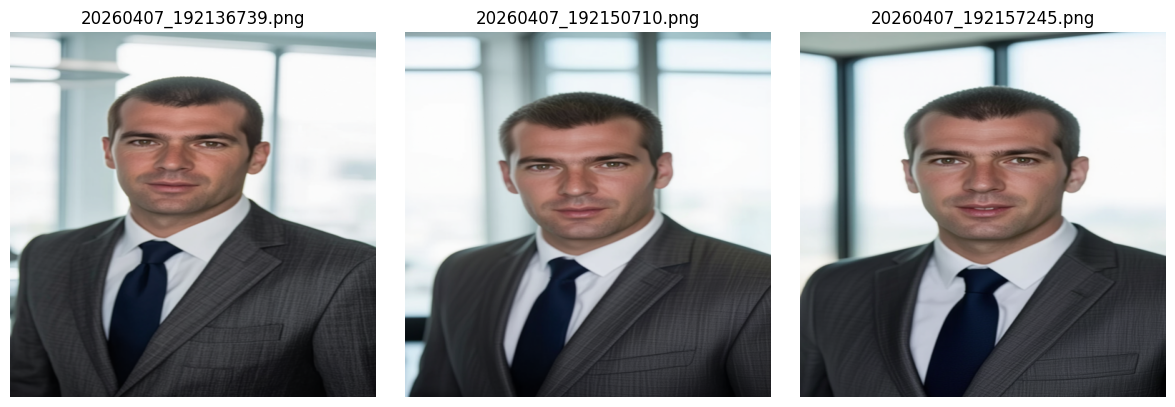

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

for i, img in enumerate(rgb_images):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(test_df.iloc[i]["image_name"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
from scipy.ndimage import gaussian_filter
import numpy as np

def compute_noise_residual(gray, sigma=1.0):
    smooth = gaussian_filter(gray, sigma=sigma)
    residual = gray - smooth
    return residual

def compute_fft_log_spectrum(gray):
    fft = np.fft.fft2(gray)
    fft_shift = np.fft.fftshift(fft)
    magnitude = np.abs(fft_shift)
    log_spectrum = np.log1p(magnitude)
    return log_spectrum

In [15]:
residual_images = []
fft_images = []

for gray in gray_images:
    residual = compute_noise_residual(gray, sigma=1.0)
    fft_log = compute_fft_log_spectrum(gray)
    residual_images.append(residual)
    fft_images.append(fft_log)

print("Computed residuals:", len(residual_images))
print("Computed FFTs:", len(fft_images))
print("Residual shape:", residual_images[0].shape)
print("FFT shape:", fft_images[0].shape)

Computed residuals: 3
Computed FFTs: 3
Residual shape: (512, 512)
FFT shape: (512, 512)


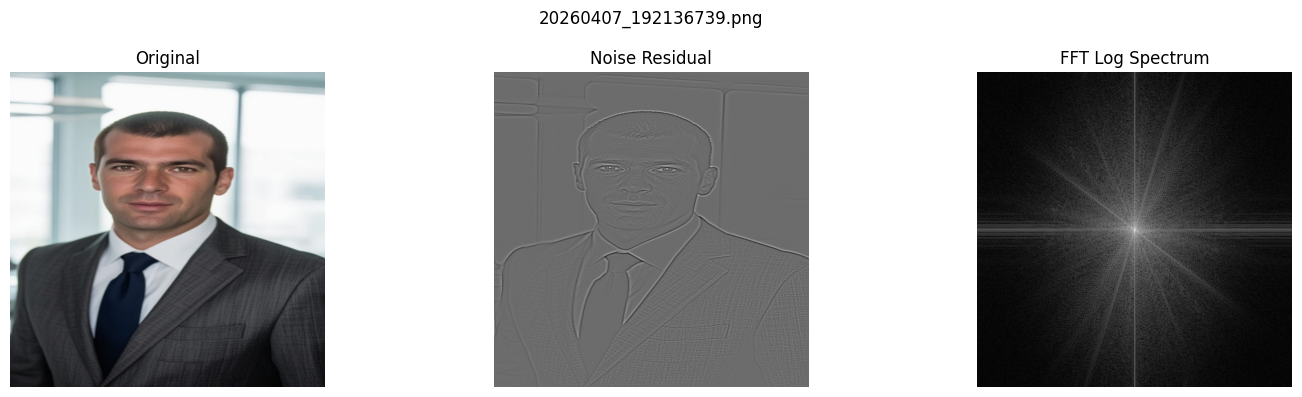

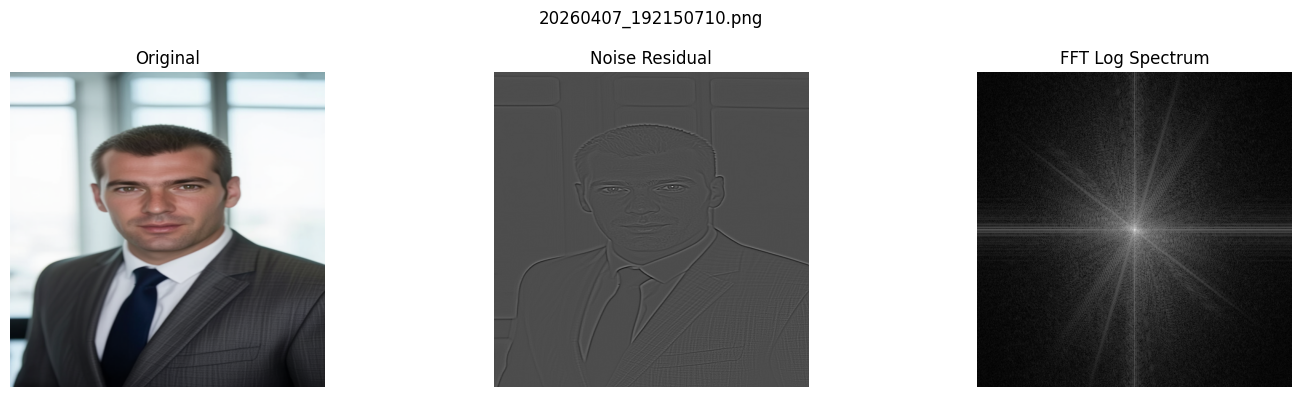

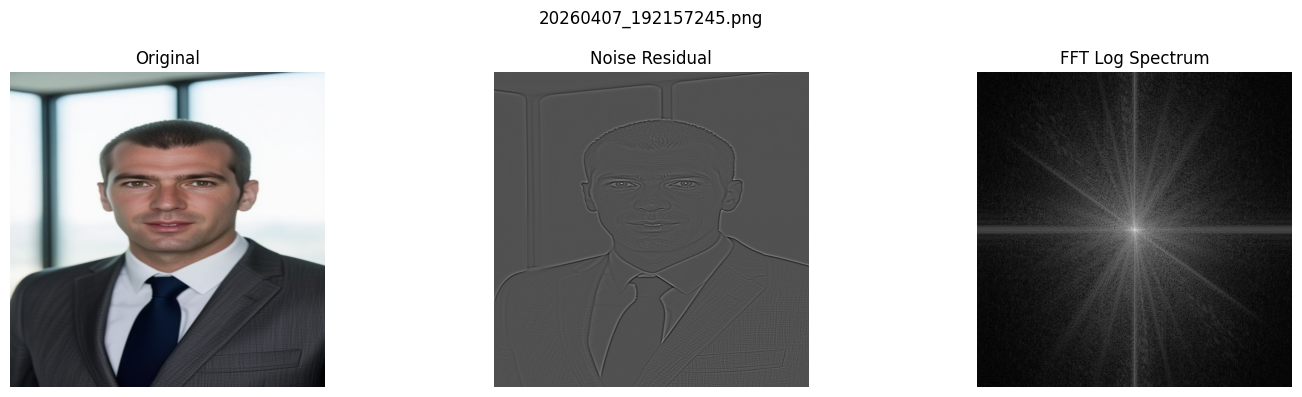

In [16]:
import matplotlib.pyplot as plt

for i in range(len(rgb_images)):
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb_images[i])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(residual_images[i], cmap="gray")
    plt.title("Noise Residual")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(fft_images[i], cmap="gray")
    plt.title("FFT Log Spectrum")
    plt.axis("off")

    plt.suptitle(test_df.iloc[i]["image_name"])
    plt.tight_layout()
    plt.show()

In [18]:
import numpy as np
from scipy.ndimage import laplace, sobel

def compute_laplacian_map(gray):
    return laplace(gray)

def compute_gradient_magnitude(gray):
    gx = sobel(gray, axis=1)
    gy = sobel(gray, axis=0)
    grad_mag = np.sqrt(gx**2 + gy**2)
    return grad_mag

In [19]:
laplacian_images = []
gradient_images = []

for gray in gray_images:
    lap_map = compute_laplacian_map(gray)
    grad_map = compute_gradient_magnitude(gray)

    laplacian_images.append(lap_map)
    gradient_images.append(grad_map)

print("Computed Laplacian maps:", len(laplacian_images))
print("Computed gradient maps:", len(gradient_images))
print("Shape:", laplacian_images[0].shape)

Computed Laplacian maps: 3
Computed gradient maps: 3
Shape: (512, 512)


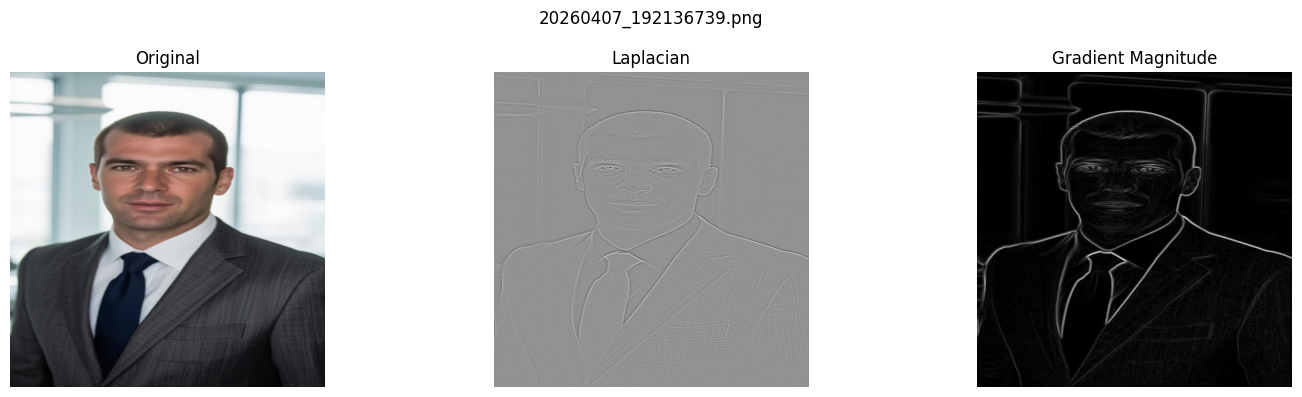

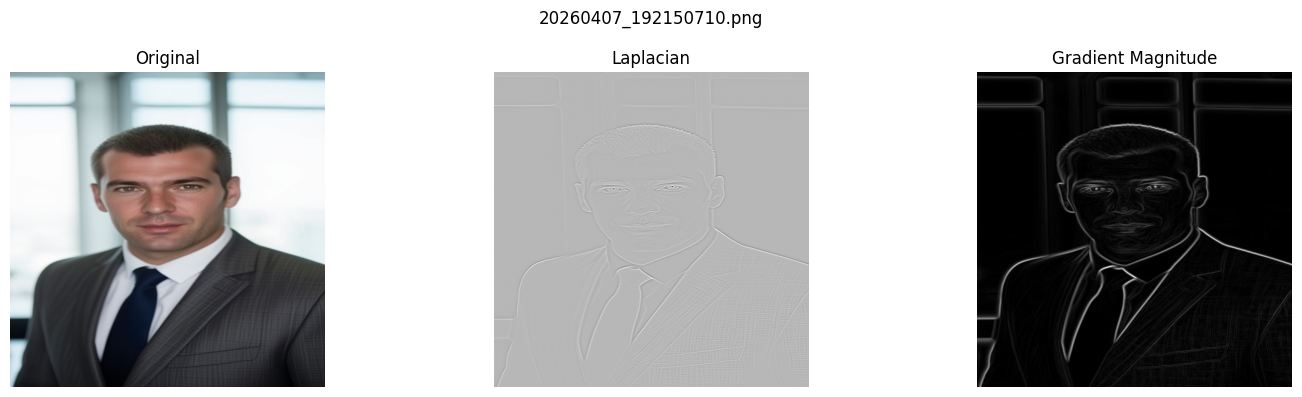

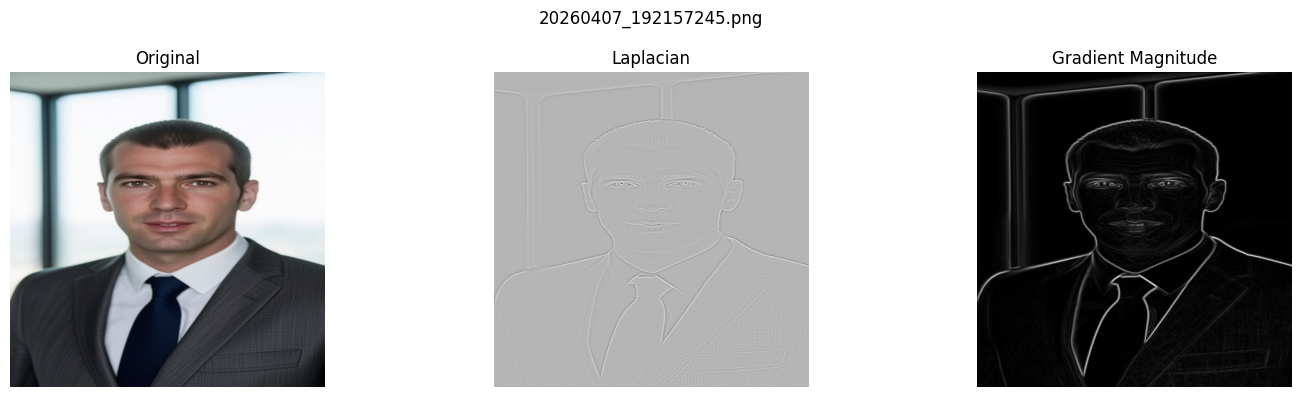

In [20]:
import matplotlib.pyplot as plt

for i in range(len(gray_images)):
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb_images[i])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(laplacian_images[i], cmap="gray")
    plt.title("Laplacian")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(gradient_images[i], cmap="gray")
    plt.title("Gradient Magnitude")
    plt.axis("off")

    plt.suptitle(test_df.iloc[i]["image_name"])
    plt.tight_layout()
    plt.show()

In [21]:
from scipy.stats import kurtosis
import pandas as pd
import numpy as np

def summarize_features(gray, residual, fft_log, lap_map, grad_map):
    feats = {
        "image_name": None,
        "gray_mean": float(np.mean(gray)),
        "gray_std": float(np.std(gray)),
        "res_mean": float(np.mean(residual)),
        "res_std": float(np.std(residual)),
        "res_kurtosis": float(kurtosis(residual.ravel(), fisher=False, bias=False)),
        "fft_mean": float(np.mean(fft_log)),
        "fft_std": float(np.std(fft_log)),
        "lap_mean": float(np.mean(lap_map)),
        "lap_std": float(np.std(lap_map)),
        "lap_kurtosis": float(kurtosis(lap_map.ravel(), fisher=False, bias=False)),
        "grad_mean": float(np.mean(grad_map)),
        "grad_std": float(np.std(grad_map)),
        "grad_max": float(np.max(grad_map)),
    }
    return feats

feature_rows = []

for i in range(len(gray_images)):
    feats = summarize_features(
        gray_images[i],
        residual_images[i],
        fft_images[i],
        laplacian_images[i],
        gradient_images[i]
    )
    feats["image_name"] = test_df.iloc[i]["image_name"]
    feature_rows.append(feats)

feature_df = pd.DataFrame(feature_rows)
feature_df

,image_name,gray_mean,gray_std,res_mean,res_std,res_kurtosis,fft_mean,fft_std,lap_mean,lap_std,lap_kurtosis,grad_mean,grad_std,grad_max
0,20260407_192136739.png,0.513084,0.336897,1.735998e-10,0.010532,26.232748,1.410048,1.175903,1.068656e-11,0.029073,30.618584,0.111022,0.208673,2.673456
1,20260407_192150710.png,0.551775,0.343201,9.345058e-11,0.009360,38.226711,1.443865,1.112613,1.136868e-11,0.026407,49.631542,0.104582,0.198493,2.581362
2,20260407_192157245.png,0.538188,0.343516,-7.275958e-12,0.011667,29.129280,1.560812,1.157364,-2.592060e-11,0.033277,35.015427,0.117772,0.238510,2.709757


In [22]:
df_full = df.dropna(subset=["Reference Image", "App", "model", "Output dir"]).copy()
df_full["Output dir"] = df_full["Output dir"].astype(int)
df_full["app_clean"] = df_full["App"].astype(str).str.strip()
df_full["model_clean"] = df_full["model"].astype(str).str.strip()
df_full["subject_name"] = df_full["Reference Image"].apply(extract_subject_name)

print("Metadata rows:", len(df_full))
df_full.head()

Metadata rows: 65


,Sl no,Reference Image,Dataset,App,Face Reference,Subject Refernce,Prompt,Negative Prompt,Generations,model,Output dir,Credits,app_clean,model_clean,subject_name
0,1,Zinedine_Zidane_0001.jpg,1,KlingAI,45.0,65.0,1,NaN,3,Image 2.1,1,2,KlingAI,Image 2.1,Zinedine_Zidane
1,2,Zinedine_Zidane_0001.jpg,1,KlingAI,45.0,65.0,2,NaN,2,Image 2.1,2,2,KlingAI,Image 2.1,Zinedine_Zidane
2,3,Zinedine_Zidane_0001.jpg,1,KlingAI,45.0,65.0,3,NaN,2,Image 2.1,3,2,KlingAI,Image 2.1,Zinedine_Zidane
3,4,Zinedine_Zidane_0001.jpg,1,KlingAI,45.0,65.0,4,NaN,2,Image 2.1,4,2,KlingAI,Image 2.1,Zinedine_Zidane
4,5,Zinedine_Zidane_0001.jpg,1,KlingAI,NaN,NaN,4,NaN,2,Image 3 Omni,5,2,KlingAI,Image 3 Omni,Zinedine_Zidane


In [23]:
def get_app_folder(app_name: str) -> Path:
    app_clean = str(app_name).strip().lower()
    if "kling" in app_clean:
        return KLING_DIR
    elif "hailuo" in app_clean:
        return HAILUO_DIR
    else:
        raise ValueError(f"Unknown app name: {app_name}")

In [24]:
all_rows = []

for _, row in df_full.iterrows():
    output_id = int(row["Output dir"])
    app_folder = get_app_folder(row["app_clean"])
    image_dir = app_folder / str(output_id)

    if not image_dir.exists() or not image_dir.is_dir():
        print(f"Skipping missing folder: {image_dir}")
        continue

    files = [x for x in sorted(image_dir.iterdir()) if x.is_file()]

    if len(files) == 0:
        print(f"No files found in: {image_dir}")
        continue

    for f in files:
        all_rows.append({
            "image_path": str(f),
            "image_name": f.name,
            "image_dir": str(image_dir),
            "app": row["app_clean"],
            "model": row["model_clean"],
            "reference_image": row["Reference Image"],
            "subject_name": row["subject_name"],
            "output_id": output_id,
        })

full_test_df = pd.DataFrame(all_rows)

print("Total images matched:", len(full_test_df))
print("Unique output folders matched:", full_test_df["output_id"].nunique())
full_test_df.head()

Total images matched: 81
Unique output folders matched: 65


,image_path,image_name,image_dir,app,model,reference_image,subject_name,output_id
0,/content/drive/MyDrive/Deepfake Dataset/KlingA...,20260407_192136739.png,/content/drive/MyDrive/Deepfake Dataset/KlingAI/1,KlingAI,Image 2.1,Zinedine_Zidane_0001.jpg,Zinedine_Zidane,1
1,/content/drive/MyDrive/Deepfake Dataset/KlingA...,20260407_192150710.png,/content/drive/MyDrive/Deepfake Dataset/KlingAI/1,KlingAI,Image 2.1,Zinedine_Zidane_0001.jpg,Zinedine_Zidane,1
2,/content/drive/MyDrive/Deepfake Dataset/KlingA...,20260407_192157245.png,/content/drive/MyDrive/Deepfake Dataset/KlingAI/1,KlingAI,Image 2.1,Zinedine_Zidane_0001.jpg,Zinedine_Zidane,1
3,/content/drive/MyDrive/Deepfake Dataset/KlingA...,20260407_193117955.png,/content/drive/MyDrive/Deepfake Dataset/KlingAI/2,KlingAI,Image 2.1,Zinedine_Zidane_0001.jpg,Zinedine_Zidane,2
4,/content/drive/MyDrive/Deepfake Dataset/KlingA...,20260407_193123170.png,/content/drive/MyDrive/Deepfake Dataset/KlingAI/2,KlingAI,Image 2.1,Zinedine_Zidane_0001.jpg,Zinedine_Zidane,2


In [25]:
print(full_test_df["app"].value_counts())
print()
print(full_test_df["model"].value_counts())

app
KlingAI     49
HailuoAI    32
Name: count, dtype: int64

model
Image 2.1             33
Image 3 Omni          16
Nano Banana Pro        8
Seedream 4.5           8
GPT Image 15           8
Image 1.0 (Hailuo)     8
Name: count, dtype: int64


In [26]:
from scipy.stats import kurtosis
from scipy.ndimage import laplace, sobel, gaussian_filter
import numpy as np
import pandas as pd

def compute_noise_residual(gray, sigma=1.0):
    smooth = gaussian_filter(gray, sigma=sigma)
    return gray - smooth

def compute_fft_log_spectrum(gray):
    fft = np.fft.fft2(gray)
    fft_shift = np.fft.fftshift(fft)
    magnitude = np.abs(fft_shift)
    return np.log1p(magnitude)

def compute_laplacian_map(gray):
    return laplace(gray)

def compute_gradient_magnitude(gray):
    gx = sobel(gray, axis=1)
    gy = sobel(gray, axis=0)
    return np.sqrt(gx**2 + gy**2)

def summarize_features(gray, residual, fft_log, lap_map, grad_map):
    return {
        "gray_mean": float(np.mean(gray)),
        "gray_std": float(np.std(gray)),
        "res_mean": float(np.mean(residual)),
        "res_std": float(np.std(residual)),
        "res_kurtosis": float(kurtosis(residual.ravel(), fisher=False, bias=False)),
        "fft_mean": float(np.mean(fft_log)),
        "fft_std": float(np.std(fft_log)),
        "lap_mean": float(np.mean(lap_map)),
        "lap_std": float(np.std(lap_map)),
        "lap_kurtosis": float(kurtosis(lap_map.ravel(), fisher=False, bias=False)),
        "grad_mean": float(np.mean(grad_map)),
        "grad_std": float(np.std(grad_map)),
        "grad_max": float(np.max(grad_map)),
    }

feature_rows = []

for idx, row in full_test_df.iterrows():
    try:
        rgb = load_image_rgb(row["image_path"])
        gray = rgb_to_gray(rgb)

        residual = compute_noise_residual(gray, sigma=1.0)
        fft_log = compute_fft_log_spectrum(gray)
        lap_map = compute_laplacian_map(gray)
        grad_map = compute_gradient_magnitude(gray)

        feats = summarize_features(gray, residual, fft_log, lap_map, grad_map)

        feature_rows.append({
            "image_path": row["image_path"],
            "image_name": row["image_name"],
            "image_dir": row["image_dir"],
            "app": row["app"],
            "model": row["model"],
            "reference_image": row["reference_image"],
            "subject_name": row["subject_name"],
            "output_id": row["output_id"],
            **feats
        })

        if (idx + 1) % 25 == 0:
            print(f"Processed {idx + 1} images")

    except Exception as e:
        print(f"Failed on {row['image_path']} -> {e}")

feature_df_full = pd.DataFrame(feature_rows)
print("Final processed images:", len(feature_df_full))
feature_df_full.head()

Processed 25 images
Processed 50 images
Processed 75 images
Final processed images: 81


,image_path,image_name,image_dir,app,model,reference_image,subject_name,output_id,gray_mean,gray_std,...,res_std,res_kurtosis,fft_mean,fft_std,lap_mean,lap_std,lap_kurtosis,grad_mean,grad_std,grad_max
0,/content/drive/MyDrive/Deepfake Dataset/KlingA...,20260407_192136739.png,/content/drive/MyDrive/Deepfake Dataset/KlingAI/1,KlingAI,Image 2.1,Zinedine_Zidane_0001.jpg,Zinedine_Zidane,1,0.513084,0.336897,...,0.010532,26.232748,1.410048,1.175903,1.068656e-11,0.029073,30.618584,0.111022,0.208673,2.673456
1,/content/drive/MyDrive/Deepfake Dataset/KlingA...,20260407_192150710.png,/content/drive/MyDrive/Deepfake Dataset/KlingAI/1,KlingAI,Image 2.1,Zinedine_Zidane_0001.jpg,Zinedine_Zidane,1,0.551775,0.343201,...,0.009360,38.226711,1.443865,1.112613,1.136868e-11,0.026407,49.631542,0.104582,0.198493,2.581362
2,/content/drive/MyDrive/Deepfake Dataset/KlingA...,20260407_192157245.png,/content/drive/MyDrive/Deepfake Dataset/KlingAI/1,KlingAI,Image 2.1,Zinedine_Zidane_0001.jpg,Zinedine_Zidane,1,0.538188,0.343516,...,0.011667,29.129280,1.560812,1.157364,-2.592060e-11,0.033277,35.015427,0.117772,0.238510,2.709757
3,/content/drive/MyDrive/Deepfake Dataset/KlingA...,20260407_193117955.png,/content/drive/MyDrive/Deepfake Dataset/KlingAI/2,KlingAI,Image 2.1,Zinedine_Zidane_0001.jpg,Zinedine_Zidane,2,0.526007,0.374716,...,0.005657,65.715195,1.015818,1.060952,1.296030e-11,0.014584,78.352577,0.060609,0.145178,2.057189
4,/content/drive/MyDrive/Deepfake Dataset/KlingA...,20260407_193123170.png,/content/drive/MyDrive/Deepfake Dataset/KlingAI/2,KlingAI,Image 2.1,Zinedine_Zidane_0001.jpg,Zinedine_Zidane,2,0.476726,0.349315,...,0.005226,64.960342,1.024250,1.044825,6.025402e-12,0.013690,77.351631,0.062893,0.132971,2.050884


In [27]:
output_dir = DATASET_ROOT / "analysis_outputs"
output_dir.mkdir(parents=True, exist_ok=True)

save_path = output_dir / "full_dataset_features.csv"
feature_df_full.to_csv(save_path, index=False)

print("Saved:", save_path)

Saved: /content/drive/MyDrive/Deepfake Dataset/analysis_outputs/full_dataset_features.csv


In [28]:
print("Images per app:")
print(feature_df_full["app"].value_counts())

print("\nImages per model:")
print(feature_df_full["model"].value_counts())

print("\nImages per subject:")
print(feature_df_full["subject_name"].value_counts())

Images per app:
app
KlingAI     49
HailuoAI    32
Name: count, dtype: int64

Images per model:
model
Image 2.1             33
Image 3 Omni          16
Nano Banana Pro        8
Seedream 4.5           8
GPT Image 15           8
Image 1.0 (Hailuo)     8
Name: count, dtype: int64

Images per subject:
subject_name
Zinedine_Zidane       21
Morgan_Freeman        20
Wei_Wu                20
Ana_Isabel_Sanchez    20
Name: count, dtype: int64


In [29]:
from sklearn.preprocessing import StandardScaler

meta_cols = [
    "image_path", "image_name", "image_dir",
    "app", "model", "reference_image",
    "subject_name", "output_id"
]

feature_cols = [c for c in feature_df_full.columns if c not in meta_cols]

X = feature_df_full[feature_cols].to_numpy(dtype=np.float32)
X = StandardScaler().fit_transform(X)

y_app = feature_df_full["app"].to_numpy()
y_model = feature_df_full["model"].to_numpy()
groups = feature_df_full["subject_name"].to_numpy()

print("Feature matrix shape:", X.shape)
print("App labels:", np.unique(y_app))
print("Model labels:", np.unique(y_model))
print("Subjects:", np.unique(groups))

Feature matrix shape: (81, 13)
App labels: ['HailuoAI' 'KlingAI']
Model labels: ['GPT Image 15' 'Image 1.0 (Hailuo)' 'Image 2.1' 'Image 3 Omni'
 'Nano Banana Pro' 'Seedream 4.5']
Subjects: ['Ana_Isabel_Sanchez' 'Morgan_Freeman' 'Wei_Wu' 'Zinedine_Zidane']


In [30]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

logo = LeaveOneGroupOut()
app_true = []
app_pred = []

for train_idx, test_idx in logo.split(X, y_app, groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_app[train_idx], y_app[test_idx]

    clf = LogisticRegression(max_iter=5000)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)

    app_true.extend(y_test)
    app_pred.extend(preds)

app_acc = accuracy_score(app_true, app_pred)
print("App classification accuracy:", app_acc)
print()
print(classification_report(app_true, app_pred))

App classification accuracy: 0.7283950617283951

              precision    recall  f1-score   support

    HailuoAI       0.66      0.66      0.66        32
     KlingAI       0.78      0.78      0.78        49

    accuracy                           0.73        81
   macro avg       0.72      0.72      0.72        81
weighted avg       0.73      0.73      0.73        81



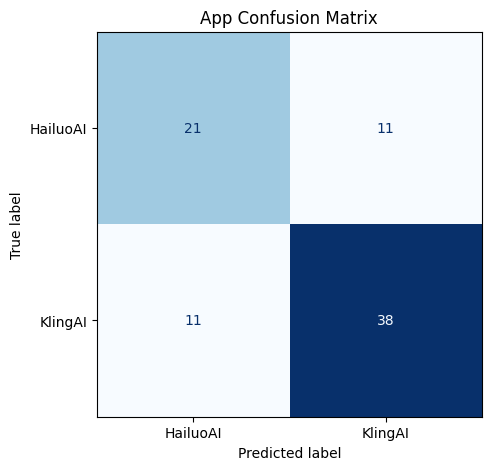

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

app_labels = np.unique(y_app)
cm_app = confusion_matrix(app_true, app_pred, labels=app_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_app, display_labels=app_labels)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("App Confusion Matrix")
plt.show()

In [32]:
from sklearn.ensemble import RandomForestClassifier

model_true = []
model_pred = []

for train_idx, test_idx in logo.split(X, y_model, groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_model[train_idx], y_model[test_idx]

    clf = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)

    model_true.extend(y_test)
    model_pred.extend(preds)

model_acc = accuracy_score(model_true, model_pred)
print("Model classification accuracy:", model_acc)
print()
print(classification_report(model_true, model_pred))

Model classification accuracy: 0.5432098765432098

                    precision    recall  f1-score   support

      GPT Image 15       0.33      0.25      0.29         8
Image 1.0 (Hailuo)       0.75      0.38      0.50         8
         Image 2.1       0.70      0.85      0.77        33
      Image 3 Omni       0.56      0.31      0.40        16
   Nano Banana Pro       0.38      0.75      0.50         8
      Seedream 4.5       0.00      0.00      0.00         8

          accuracy                           0.54        81
         macro avg       0.45      0.42      0.41        81
      weighted avg       0.54      0.54      0.52        81



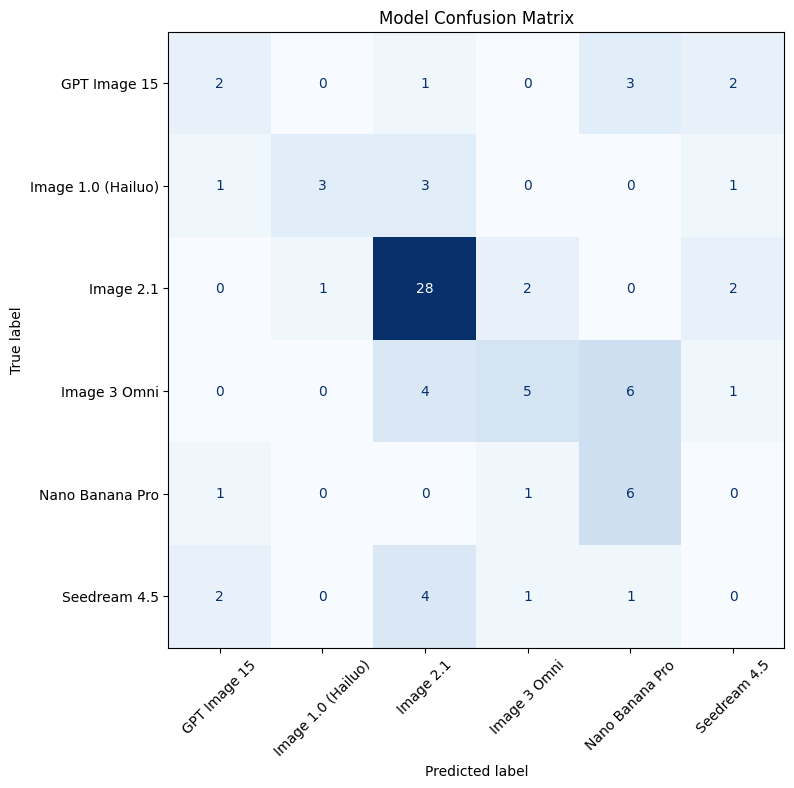

In [33]:
model_labels = np.unique(y_model)
cm_model = confusion_matrix(model_true, model_pred, labels=model_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_model, display_labels=model_labels)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
plt.title("Model Confusion Matrix")
plt.show()

In [34]:
rf_full = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_full.fit(X, y_model)

importances = rf_full.feature_importances_
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
5,fft_mean,0.144676
8,lap_std,0.115834
6,fft_std,0.101315
10,grad_mean,0.097732
3,res_std,0.091443
9,lap_kurtosis,0.073624
12,grad_max,0.067929
4,res_kurtosis,0.064116
1,gray_std,0.060301
11,grad_std,0.051425


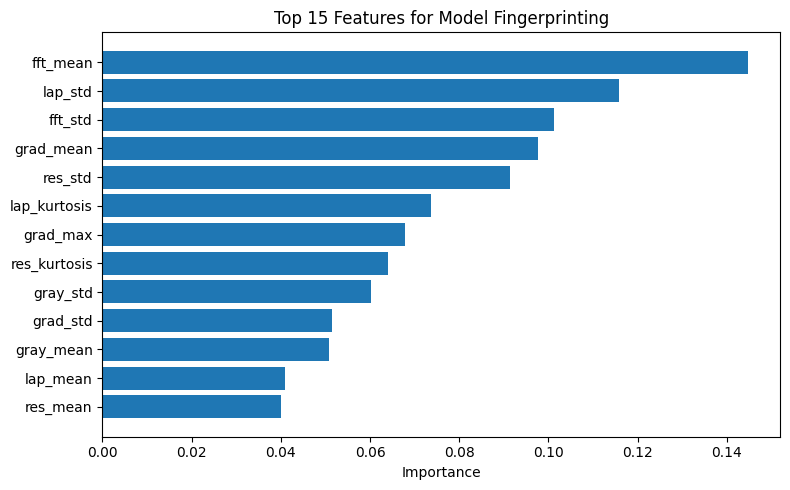

In [35]:
top_n = 15
top_features = importance_df.head(top_n)

plt.figure(figsize=(8, 5))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 15 Features for Model Fingerprinting")
plt.tight_layout()
plt.show()

In [36]:
results_dir = DATASET_ROOT / "analysis_outputs"
results_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame({
    "true_app": app_true,
    "pred_app": app_pred
}).to_csv(results_dir / "app_predictions.csv", index=False)

pd.DataFrame({
    "true_model": model_true,
    "pred_model": model_pred
}).to_csv(results_dir / "model_predictions.csv", index=False)

importance_df.to_csv(results_dir / "model_feature_importance.csv", index=False)

print("Saved:")
print(results_dir / "app_predictions.csv")
print(results_dir / "model_predictions.csv")
print(results_dir / "model_feature_importance.csv")

Saved:
/content/drive/MyDrive/Deepfake Dataset/analysis_outputs/app_predictions.csv
/content/drive/MyDrive/Deepfake Dataset/analysis_outputs/model_predictions.csv
/content/drive/MyDrive/Deepfake Dataset/analysis_outputs/model_feature_importance.csv


In [37]:
all_feature_cols = [
    "gray_mean", "gray_std",
    "res_mean", "res_std", "res_kurtosis",
    "fft_mean", "fft_std",
    "lap_mean", "lap_std", "lap_kurtosis",
    "grad_mean", "grad_std", "grad_max"
]

feature_groups = {
    "residual_only": ["res_mean", "res_std", "res_kurtosis"],
    "fft_only": ["fft_mean", "fft_std"],
    "laplacian_only": ["lap_mean", "lap_std", "lap_kurtosis"],
    "gradient_only": ["grad_mean", "grad_std", "grad_max"],
    "all_combined": all_feature_cols
}

feature_groups

{'residual_only': ['res_mean', 'res_std', 'res_kurtosis'],
 'fft_only': ['fft_mean', 'fft_std'],
 'laplacian_only': ['lap_mean', 'lap_std', 'lap_kurtosis'],
 'gradient_only': ['grad_mean', 'grad_std', 'grad_max'],
 'all_combined': ['gray_mean',
  'gray_std',
  'res_mean',
  'res_std',
  'res_kurtosis',
  'fft_mean',
  'fft_std',
  'lap_mean',
  'lap_std',
  'lap_kurtosis',
  'grad_mean',
  'grad_std',
  'grad_max']}

In [38]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def evaluate_feature_group(df, feature_cols, app_col="app", model_col="model", group_col="subject_name"):
    X = df[feature_cols].to_numpy(dtype=np.float32)
    X = StandardScaler().fit_transform(X)

    y_app = df[app_col].to_numpy()
    y_model = df[model_col].to_numpy()
    groups = df[group_col].to_numpy()

    logo = LeaveOneGroupOut()

    # App classification
    app_true, app_pred = [], []
    for train_idx, test_idx in logo.split(X, y_app, groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_app[train_idx], y_app[test_idx]

        clf = LogisticRegression(max_iter=5000)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)

        app_true.extend(y_test)
        app_pred.extend(preds)

    app_acc = accuracy_score(app_true, app_pred)

    # Model classification
    model_true, model_pred = [], []
    for train_idx, test_idx in logo.split(X, y_model, groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_model[train_idx], y_model[test_idx]

        clf = RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)

        model_true.extend(y_test)
        model_pred.extend(preds)

    model_acc = accuracy_score(model_true, model_pred)

    return {
        "n_features": len(feature_cols),
        "app_accuracy": app_acc,
        "model_accuracy": model_acc
    }

In [39]:
comparison_rows = []

for group_name, cols in feature_groups.items():
    result = evaluate_feature_group(feature_df_full, cols)
    comparison_rows.append({
        "feature_group": group_name,
        "n_features": result["n_features"],
        "app_accuracy": result["app_accuracy"],
        "model_accuracy": result["model_accuracy"]
    })
    print(f"Done: {group_name}")

comparison_df = pd.DataFrame(comparison_rows).sort_values("app_accuracy", ascending=False)
comparison_df

Done: residual_only
Done: fft_only
Done: laplacian_only
Done: gradient_only
Done: all_combined


,feature_group,n_features,app_accuracy,model_accuracy
3,gradient_only,3,0.790123,0.456790
4,all_combined,13,0.728395,0.543210
1,fft_only,2,0.679012,0.518519
2,laplacian_only,3,0.629630,0.432099
0,residual_only,3,0.617284,0.469136


In [40]:
comparison_df_model = comparison_df.sort_values("model_accuracy", ascending=False)
comparison_df_model

,feature_group,n_features,app_accuracy,model_accuracy
4,all_combined,13,0.728395,0.543210
1,fft_only,2,0.679012,0.518519
0,residual_only,3,0.617284,0.469136
3,gradient_only,3,0.790123,0.456790
2,laplacian_only,3,0.629630,0.432099


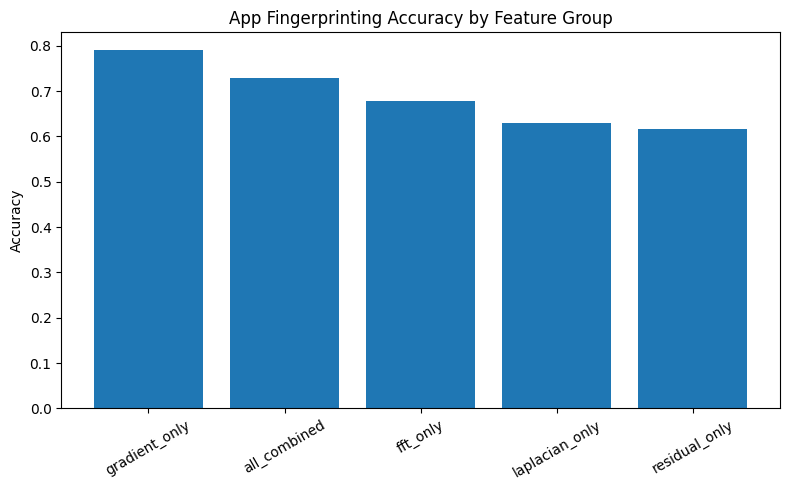

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(comparison_df["feature_group"], comparison_df["app_accuracy"])
plt.ylabel("Accuracy")
plt.title("App Fingerprinting Accuracy by Feature Group")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

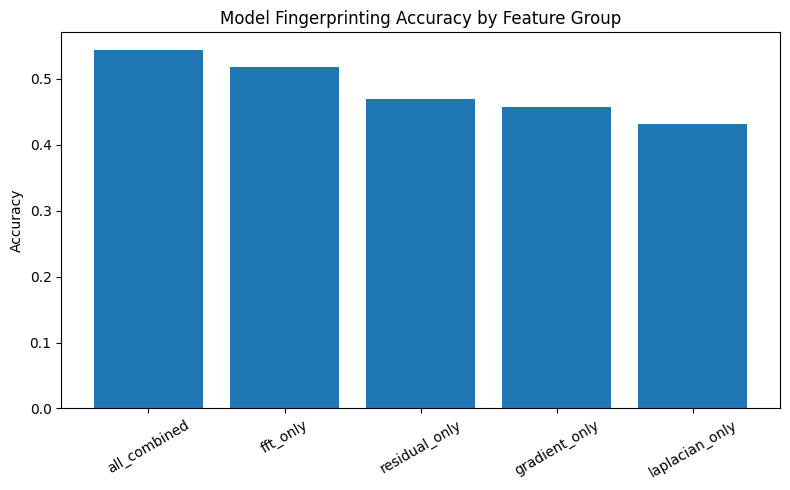

In [42]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df_model["feature_group"], comparison_df_model["model_accuracy"])
plt.ylabel("Accuracy")
plt.title("Model Fingerprinting Accuracy by Feature Group")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [43]:
results_dir = DATASET_ROOT / "analysis_outputs"
results_dir.mkdir(parents=True, exist_ok=True)

comparison_df.to_csv(results_dir / "feature_group_comparison.csv", index=False)

print("Saved:", results_dir / "feature_group_comparison.csv")
comparison_df

Saved: /content/drive/MyDrive/Deepfake Dataset/analysis_outputs/feature_group_comparison.csv


,feature_group,n_features,app_accuracy,model_accuracy
3,gradient_only,3,0.790123,0.456790
4,all_combined,13,0.728395,0.543210
1,fft_only,2,0.679012,0.518519
2,laplacian_only,3,0.629630,0.432099
0,residual_only,3,0.617284,0.469136
